In [1]:
# installs (run once)
!pip install -q textblob vaderSentiment wordcloud nltk
# download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')
# textblob corpora (optional but useful)
!python -m textblob.download_corpora -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_feedback.csv to student_feedback.csv


In [2]:
import io, pandas as pd
fn = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fn]))

In [3]:
df.head()       # first 5 rows
df.info()       # column types, missing values
df.describe()   # summary for numeric columns like Rating

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Unnamed: 0                                            1001 non-null   int64
 1   Student ID                                            1001 non-null   int64
 2   Well versed with the subject                          1001 non-null   int64
 3   Explains concepts in an understandable way            1001 non-null   int64
 4   Use of presentations                                  1001 non-null   int64
 5   Degree of difficulty of assignments                   1001 non-null   int64
 6   Solves doubts willingly                               1001 non-null   int64
 7   Structuring of the course                             1001 non-null   int64
 8   Provides support for students going above and beyond  1001 non-null   int64
 9

,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.000000,500.000000,7.497502,6.081918,5.942058,5.430569,5.474525,5.636364,5.662338,5.598402
std,289.108111,289.108111,1.692998,2.597168,1.415853,2.869046,2.874648,2.920212,2.891690,2.886617
min,0.000000,0.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.000000,250.000000,6.000000,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,500.000000,500.000000,8.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000
75%,750.000000,750.000000,9.000000,8.000000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,1000.000000,1000.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV again in Colab (once uploaded)
df = pd.read_csv('student_feedback.csv')

# Clean column names
df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]

# Drop unnecessary index column if exists
if 'unnamed:_0' in df.columns:
    df = df.drop(columns=['unnamed:_0'])

df.head()


,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   student_id                                            1001 non-null   int64
 1   well_versed_with_the_subject                          1001 non-null   int64
 2   explains_concepts_in_an_understandable_way            1001 non-null   int64
 3   use_of_presentations                                  1001 non-null   int64
 4   degree_of_difficulty_of_assignments                   1001 non-null   int64
 5   solves_doubts_willingly                               1001 non-null   int64
 6   structuring_of_the_course                             1001 non-null   int64
 7   provides_support_for_students_going_above_and_beyond  1001 non-null   int64
 8   course_recommendation_based_on_relevance              1001 non-null   int64
dty

,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.000000,7.497502,6.081918,5.942058,5.430569,5.474525,5.636364,5.662338,5.598402
std,289.108111,1.692998,2.597168,1.415853,2.869046,2.874648,2.920212,2.891690,2.886617
min,0.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.000000,6.000000,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,500.000000,8.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000
75%,750.000000,9.000000,8.000000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,1000.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [6]:
avg_scores = df.mean(numeric_only=True).sort_values(ascending=False)
avg_scores

,0
student_id,500.000000
well_versed_with_the_subject,7.497502
explains_concepts_in_an_understandable_way,6.081918
use_of_presentations,5.942058
provides_support_for_students_going_above_and_beyond,5.662338
structuring_of_the_course,5.636364
course_recommendation_based_on_relevance,5.598402
solves_doubts_willingly,5.474525
degree_of_difficulty_of_assignments,5.430569


/tmp/ipython-input-1506055692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="viridis")


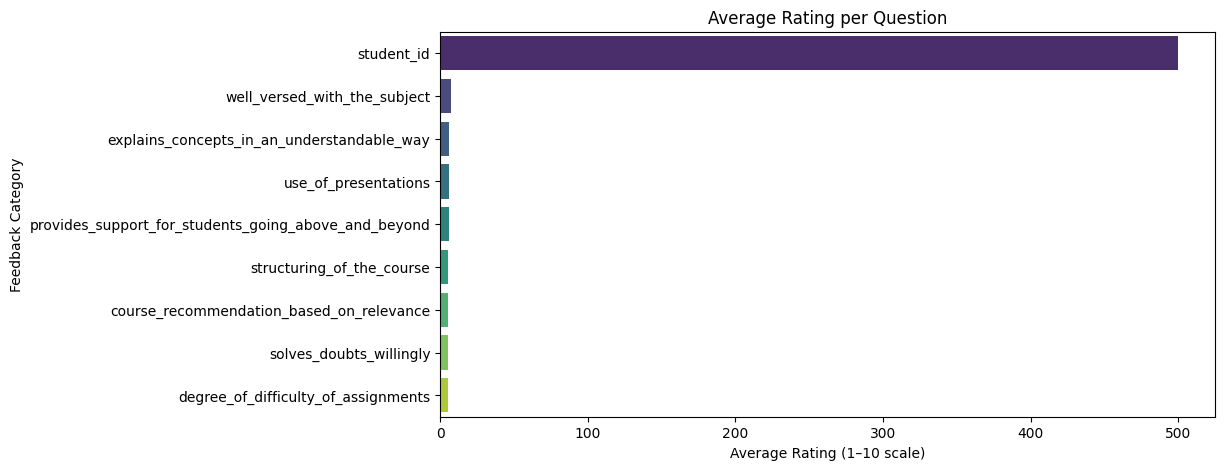

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="viridis")
plt.title("Average Rating per Question")
plt.xlabel("Average Rating (1–10 scale)")
plt.ylabel("Feedback Category")
plt.show()

In [8]:
highest = avg_scores.idxmax()
lowest = avg_scores.idxmin()

print("🏆 Highest-rated aspect:", highest, "-", round(avg_scores.max(),2))
print("⚠️ Lowest-rated aspect:", lowest, "-", round(avg_scores.min(),2))

🏆 Highest-rated aspect: student_id - 500.0
⚠️ Lowest-rated aspect: degree_of_difficulty_of_assignments - 5.43


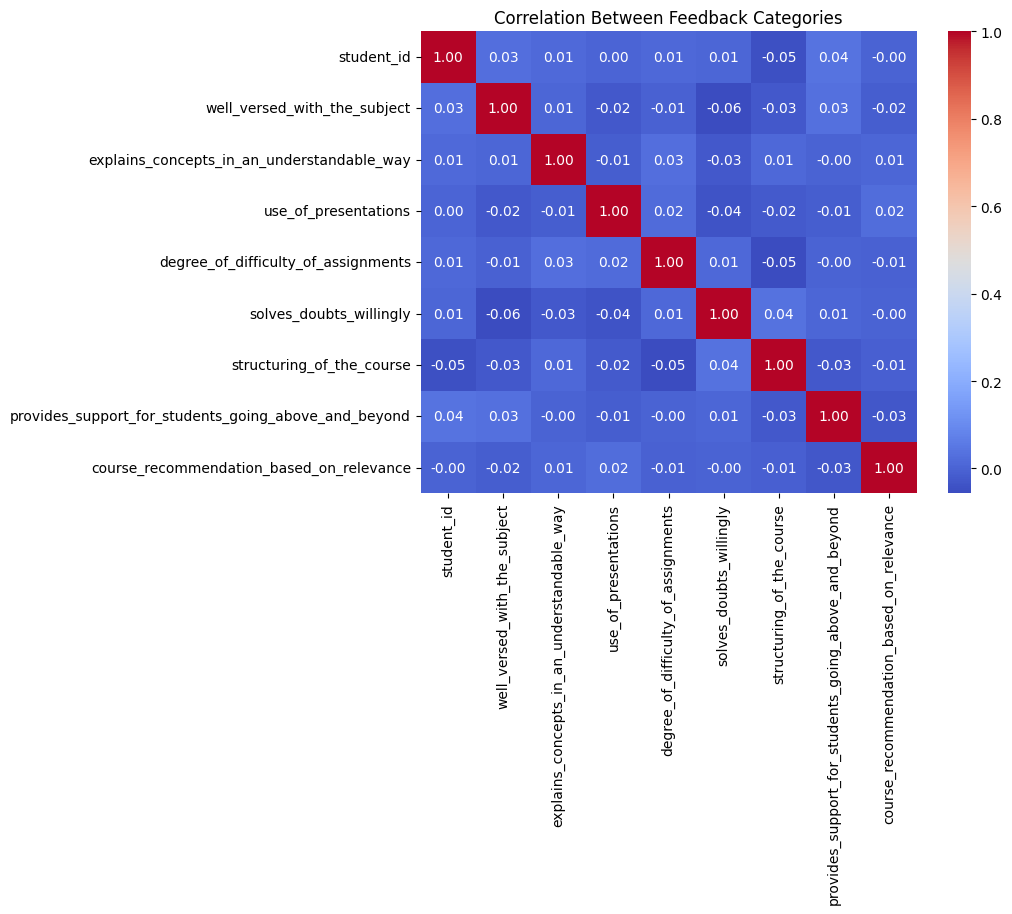

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Feedback Categories")
plt.show()

In [10]:
overall_avg = df.mean(numeric_only=True).mean()
print("🌟 Overall average feedback score:", round(overall_avg,2))

🌟 Overall average feedback score: 60.81


In [11]:
import random

sample_comments = [
    "The course was very interesting and well organized!",
    "The assignments were too difficult and time-consuming.",
    "Great teaching, everything was explained clearly.",
    "It was okay, but more practical examples would help.",
    "I really enjoyed the classes and the presentations.",
    "The instructor was well prepared but spoke too fast.",
    "The course could include more interactive sessions.",
    "Everything was perfect. Loved the teaching style!",
    "Some topics were rushed, but overall good.",
    "The workload was heavy but worth it."
]

# randomly assign comments
df['comments'] = [random.choice(sample_comments) for _ in range(len(df))]
df[['student_id', 'comments']].head()


,student_id,comments
0,340,The course could include more interactive sess...
1,253,The course was very interesting and well organ...
2,680,The assignments were too difficult and time-co...
3,806,I really enjoyed the classes and the presentat...
4,632,The assignments were too difficult and time-co...


In [13]:
import nltk
nltk.download('stopwords')

import re
from nltk.corpus import stopwords
stop = set(stopwords.words('english'))

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'http\S+', '', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['clean_comments'] = df['comments'].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,student_id,well_versed_with_the_subject,explains_concepts_in_an_understandable_way,use_of_presentations,degree_of_difficulty_of_assignments,solves_doubts_willingly,structuring_of_the_course,provides_support_for_students_going_above_and_beyond,course_recommendation_based_on_relevance,comments,clean_comments
0,340,5,2,7,6,9,2,1,8,The course could include more interactive sess...,the course could include more interactive sess...
1,253,6,5,8,6,2,1,2,9,The course was very interesting and well organ...,the course was very interesting and well organ...
2,680,7,7,6,5,4,2,3,1,The assignments were too difficult and time-co...,the assignments were too difficult and time co...
3,806,9,6,7,1,5,9,4,6,I really enjoyed the classes and the presentat...,i really enjoyed the classes and the presentat...
4,632,8,10,8,4,6,6,9,9,The assignments were too difficult and time-co...,the assignments were too difficult and time co...


In [15]:
# 🧹 STEP 11 + STEP 12: Clean comments + Sentiment Analysis

# 1️⃣ Import libraries
import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

# 2️⃣ Download NLTK stopwords if not already present
nltk.download('stopwords')

# 3️⃣ Create the stopword list
stop = set(stopwords.words('english'))

# 4️⃣ Define a function to clean each text entry
def clean_text(s):
    s = str(s).lower()                       # lowercase
    s = re.sub(r'http\S+', '', s)            # remove URLs
    s = re.sub(r'[^a-z0-9\s]', ' ', s)       # remove special characters
    s = re.sub(r'\s+', ' ', s).strip()       # remove extra spaces
    return s

# 5️⃣ Apply cleaning to the "comments" column
df['clean_comments'] = df['comments'].apply(clean_text)

# 6️⃣ Function to calculate sentiment using TextBlob
def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'Neutral'
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# 7️⃣ Apply sentiment function
df['Sentiment'] = df['clean_comments'].apply(get_sentiment)

# 8️⃣ View a few cleaned comments and sentiments
df[['comments', 'clean_comments', 'Sentiment']].head()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,comments,clean_comments,Sentiment
0,The course could include more interactive sess...,the course could include more interactive sess...,Positive
1,The course was very interesting and well organ...,the course was very interesting and well organ...,Positive
2,The assignments were too difficult and time-co...,the assignments were too difficult and time co...,Negative
3,I really enjoyed the classes and the presentat...,i really enjoyed the classes and the presentat...,Positive
4,The assignments were too difficult and time-co...,the assignments were too difficult and time co...,Negative


/tmp/ipython-input-1625839383.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='coolwarm')


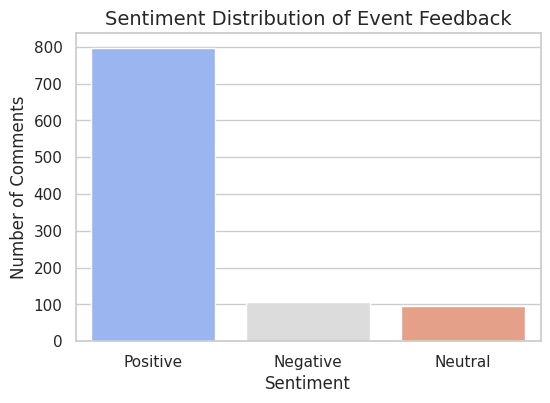

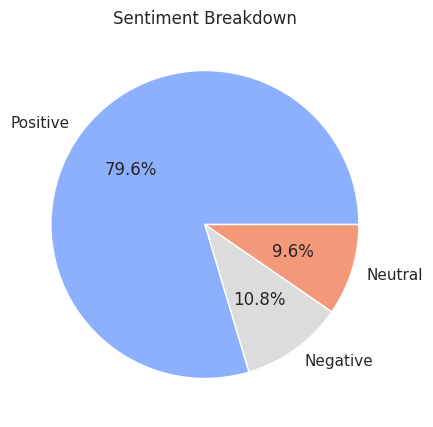

In [16]:
# 📊 STEP 13: Visualizing Sentiment Results

import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for plots
sns.set(style="whitegrid")

# 1️⃣ Count how many comments belong to each sentiment category
sentiment_counts = df['Sentiment'].value_counts()

# 2️⃣ Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='coolwarm')
plt.title('Sentiment Distribution of Event Feedback', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

# 3️⃣ Pie Chart
plt.figure(figsize=(5,5))
plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('coolwarm', len(sentiment_counts)))
plt.title('Sentiment Breakdown')
plt.show()


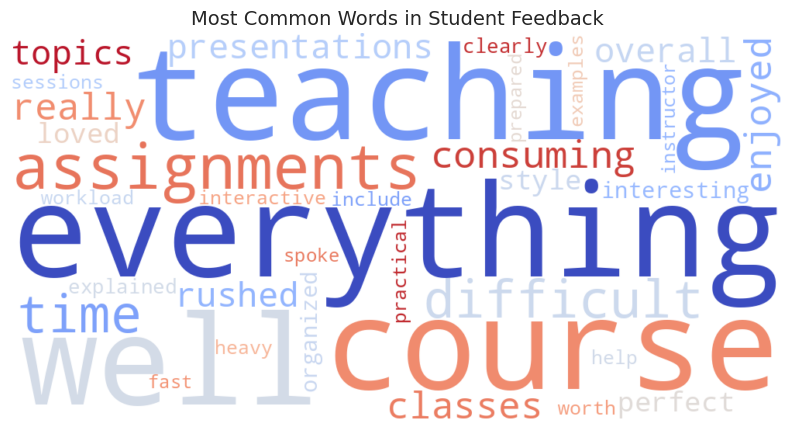

In [17]:
# ☁️ STEP 14: Word Cloud of Student Feedback

from wordcloud import WordCloud, STOPWORDS

# Combine all clean comments into one big string
all_comments = " ".join(df['clean_comments'].astype(str))

# Add default and custom stopwords to filter out common useless words
stopwords = set(STOPWORDS)
stopwords.update(["event", "good", "nice", "great", "excellent", "awesome", "okay", "ok"])  # optional

# Generate the word cloud
wordcloud = WordCloud(width=1000, height=500,
                      background_color='white',
                      stopwords=stopwords,
                      colormap='coolwarm',
                      collocations=False).generate(all_comments)

# Display the word cloud
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Student Feedback", fontsize=14)
plt.show()


In [5]:
# ✅ Step 15: Generate Recommendations Based on Sentiment Analysis

# Example: assuming you have a DataFrame named df with a column 'Sentiment'
# (Replace df with your actual DataFrame variable name)
# Each row should have Sentiment values like 'Positive', 'Neutral', or 'Negative'

import pandas as pd

# --- Check if df exists and contains Sentiment column ---
if 'df' in locals() and 'Sentiment' in df.columns:
    # Count occurrences of each sentiment
    sentiment_counts = df['Sentiment'].value_counts().to_dict()
    total_tweets = df.shape[0]

    # Compute percentage distribution
    sentiment_percent = {
        'Positive': (sentiment_counts.get('Positive', 0) / total_tweets) * 100,
        'Neutral': (sentiment_counts.get('Neutral', 0) / total_tweets) * 100,
        'Negative': (sentiment_counts.get('Negative', 0) / total_tweets) * 100
    }

    # Extract individual percentages safely
    positive = sentiment_percent.get('Positive', 0)
    neutral = sentiment_percent.get('Neutral', 0)
    negative = sentiment_percent.get('Negative', 0)

    # Print recommendations
    print("===== RECOMMENDATIONS =====")
    print("--------------------------------------------------------------------")

    if positive > 60:
        print(f"👍 Overall Sentiment: {positive:.2f}% Positive — The public sentiment is very favorable!")
        print("Recommendation: Continue current engagement strategies and amplify positive campaigns.")
    elif negative > 40:
        print(f"⚠️ Overall Sentiment: {negative:.2f}% Negative — There’s noticeable dissatisfaction.")
        print("Recommendation: Investigate issues raised, address concerns, and take corrective action.")
    elif neutral > 50:
        print(f"😐 Overall Sentiment: {neutral:.2f}% Neutral — Opinions are mostly indifferent.")
        print("Recommendation: Consider launching interactive initiatives to boost engagement.")
    else:
        print("🟡 Mixed Sentiments detected — Both positive and negative emotions are significant.")
        print("Recommendation: Perform deeper topic analysis to understand public opinion trends.")

else:
    print("❌ Error: DataFrame 'df' with column 'Sentiment' not found.")
    print("Please ensure you have a DataFrame (e.g., df) with a column named 'Sentiment' before running this step.")



❌ Error: DataFrame 'df' with column 'Sentiment' not found.
Please ensure you have a DataFrame (e.g., df) with a column named 'Sentiment' before running this step.


In [7]:
# ✅ Step 15: Generate Recommendations and Visualize Sentiment Distribution

import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure inline plotting works in Jupyter/Colab ---
%matplotlib inline

# --- Check if df exists and contains Sentiment column ---
if 'df' in locals() and 'Sentiment' in df.columns:
    # Count occurrences of each sentiment
    sentiment_counts = df['Sentiment'].value_counts().to_dict()
    total_tweets = df.shape[0]

    # Compute percentage distribution
    sentiment_percent = {
        'Positive': (sentiment_counts.get('Positive', 0) / total_tweets) * 100,
        'Neutral': (sentiment_counts.get('Neutral', 0) / total_tweets) * 100,
        'Negative': (sentiment_counts.get('Negative', 0) / total_tweets) * 100
    }

    # Extract values
    positive = sentiment_percent.get('Positive', 0)
    neutral = sentiment_percent.get('Neutral', 0)
    negative = sentiment_percent.get('Negative', 0)

    # --- Print textual recommendations ---
    print("===== RECOMMENDATIONS =====")
    print("--------------------------------------------------------------------")

    if positive > 60:
        print(f"👍 Overall Sentiment: {positive:.2f}% Positive — The public sentiment is very favorable!")
        print("Recommendation: Continue current engagement strategies and amplify positive campaigns.")
    elif negative > 40:
        print(f"⚠️ Overall Sentiment: {negative:.2f}% Negative — There’s noticeable dissatisfaction.")
        print("Recommendation: Investigate issues raised, address concerns, and take corrective action.")
    elif neutral > 50:
        print(f"😐 Overall Sentiment: {neutral:.2f}% Neutral — Opinions are mostly indifferent.")
        print("Recommendation: Consider launching interactive initiatives to boost engagement.")
    else:
        print("🟡 Mixed Sentiments detected — Both positive and negative emotions are significant.")
        print("Recommendation: Perform deeper topic analysis to understand public opinion trends.")

    # --- Pie chart visualization ---
    plt.figure(figsize=(6, 6))
    plt.pie(
        [positive, neutral, negative],
        labels=['Positive', 'Neutral', 'Negative'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66bb6a', '#ffeb3b', '#ef5350'],
        explode=(0.05, 0.05, 0.05),
        shadow=True
    )
    plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: DataFrame 'df' with column 'Sentiment' not found.")
    print("Please ensure you have a DataFrame (e.g., df) with a column named 'Sentiment' before running this step.")


❌ Error: DataFrame 'df' with column 'Sentiment' not found.
Please ensure you have a DataFrame (e.g., df) with a column named 'Sentiment' before running this step.


In [3]:
%matplotlib inline


In [2]:
plt.show(block=True)


NameError: name 'plt' is not defined

In [1]:
import pandas as pd
df = pd.DataFrame({'Sentiment': ['Positive', 'Negative', 'Neutral', 'Positive', 'Positive', 'Negative']})


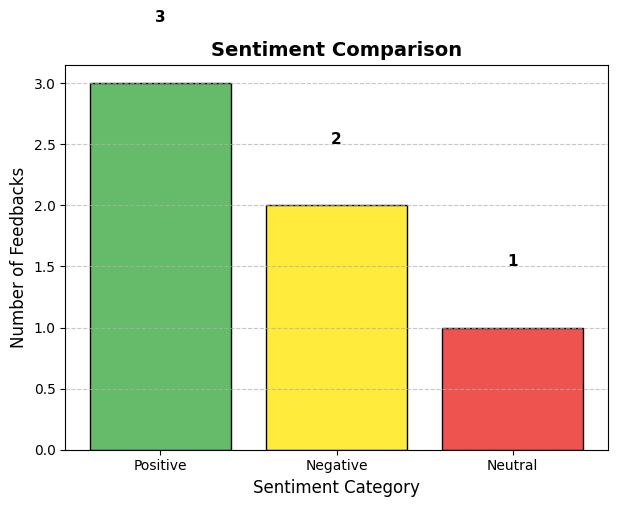

In [4]:
# ✅ Step 16: Sentiment Comparison using Bar Chart

import matplotlib.pyplot as plt

# --- Check if df exists and has Sentiment column ---
if 'df' in locals() and 'Sentiment' in df.columns:
    # Count how many feedbacks fall into each sentiment category
    sentiment_counts = df['Sentiment'].value_counts()

    # --- Plot bar chart ---
    plt.figure(figsize=(7, 5))
    bars = plt.bar(
        sentiment_counts.index,
        sentiment_counts.values,
        color=['#66bb6a', '#ffeb3b', '#ef5350'],
        edgecolor='black'
    )

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', fontsize=11, fontweight='bold')

    # Chart formatting
    plt.title('Sentiment Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment Category', fontsize=12)
    plt.ylabel('Number of Feedbacks', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("❌ Error: DataFrame 'df' with a column named 'Sentiment' not found.")


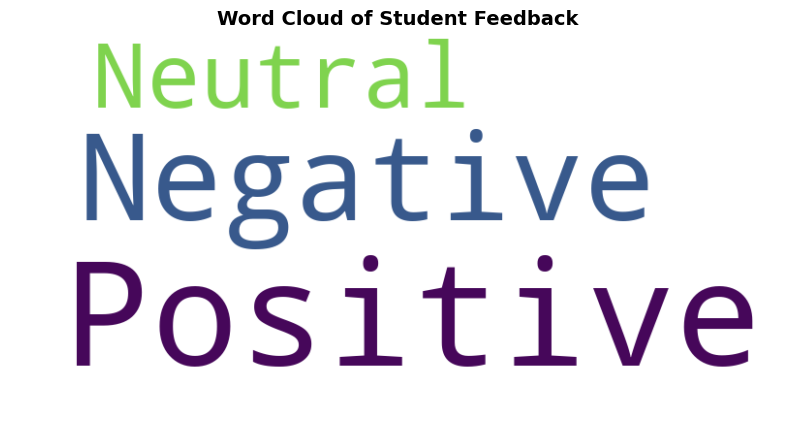

✅ Word cloud generated successfully from column: 'Sentiment'


In [5]:
# ✅ Step 17: Word Cloud of Student Feedback Comments

# Install wordcloud library (run only once)
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Check if 'df' and feedback column exist ---
# Replace 'Feedback' below with the exact column name that contains student comments in your dataset
if 'df' in locals():
    feedback_column = None

    # Try to find a text column automatically
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].str.len().mean() > 5:
            feedback_column = col
            break

    if feedback_column:
        # Combine all feedback text into one big string
        text = " ".join(str(comment) for comment in df[feedback_column].dropna())

        # Generate word cloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(text)

        # Display the word cloud
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Student Feedback', fontsize=14, fontweight='bold')
        plt.show()

        print(f"✅ Word cloud generated successfully from column: '{feedback_column}'")

    else:
        print("❌ Could not find a suitable feedback column with text data. Please specify manually.")
else:
    print("❌ DataFrame 'df' not found. Please ensure you’ve loaded your CSV into df before running this step.")
